# Late Opening Forecast: Consensus Benchmark

Task definition: forecast nominal domestic opening-weekend gross for ex-ante commercial releases, using only published estimates available before actual opening-weekend performance is known. For this late-forecast benchmark, the existence of a valid published estimate is treated as the commercial/wide-release screen.

This notebook freezes the first-pass forecast origin as the latest estimate dated on or before the Thursday before the opening Friday. Because the EDA estimate table stores dates rather than timestamps, this operationalizes "Thursday 11:59 PM before opening Friday" as `estimate_date <= opening_weekend_start - 1 day`.

The Numbers predictions are excluded by default until their behavior is audited separately. Release years 2020 and 2021 are also excluded from the clean first pass.

In [3]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "pm-box-office-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(tempfile.gettempdir(), "pm-box-office-cache"))

repo_root = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

from pm_box_office.db.connection import connect_database

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.options.display.float_format = "{:,.4f}".format

## Parameters

The benchmark deliberately uses a narrow information set. Change these constants only when the forecast origin or eligible movie universe changes.

In [4]:
FORECAST_ORIGIN_LABEL = "latest estimate dated by Thursday before opening Friday"
CUTOFF_DAYS_BEFORE_OPENING_WEEKEND = 1
EXCLUDED_ESTIMATE_SOURCES = {"the_numbers_predictions"}
EXCLUDED_RELEASE_YEARS = {2020, 2021}
TRAIN_TEST_SPLITS = {
    "2010-2019_and_2022-2023_train__2024plus_test": {
        "train_years": set(range(2010, 2020)) | {2022, 2023},
        "test_start_year": 2024,
    },
    "2022-2023_train__2024plus_test": {
        "train_years": {2022, 2023},
        "test_start_year": 2024,
    },
}
MIN_GROUP_N_FOR_GROUP_SIGMA = 10

## Load EDA Tables

Run `eda/create_plotting_tables.py` first if these derived analytics tables are stale or missing.

In [5]:
openings_sql = """
SELECT
    release_run_id,
    movie_id,
    title,
    opening_date,
    opening_weekend_start,
    release_year,
    release_month,
    season_bucket,
    market,
    release_type,
    release_width_bucket,
    is_wide_release,
    is_large_release,
    genre,
    distributor,
    franchise,
    is_franchise,
    opening_weekend_theaters,
    opening_weekend_gross_usd
FROM analytics.eda_movie_openings
WHERE opening_weekend_gross_usd IS NOT NULL
"""

estimates_sql = """
SELECT
    eda_estimate_id,
    estimate_source,
    source_prediction_id,
    release_run_id,
    movie_id,
    title,
    opening_date,
    opening_weekend_start,
    actual_opening_weekend_gross_usd,
    release_width_bucket,
    genre,
    distributor,
    franchise,
    is_franchise,
    estimate_date,
    target_start_date,
    target_end_date,
    forecast_metric,
    estimate_low_usd,
    estimate_high_usd,
    estimate_mid_usd,
    estimate_width_usd,
    actual_inside_range,
    days_before_opening_weekend
FROM analytics.eda_news_estimates
WHERE estimate_mid_usd IS NOT NULL
"""

conn = connect_database()
try:
    openings = pd.read_sql_query(openings_sql, conn.raw)
    estimates = pd.read_sql_query(estimates_sql, conn.raw)
finally:
    conn.close()

for df in (openings, estimates):
    for col in ["opening_date", "opening_weekend_start", "estimate_date", "target_start_date", "target_end_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

openings.shape, estimates.shape

/var/folders/9w/tkd5myg15nqbl66qxtspnnf80000gn/T/ipykernel_74731/668574388.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  openings = pd.read_sql_query(openings_sql, conn.raw)
/var/folders/9w/tkd5myg15nqbl66qxtspnnf80000gn/T/ipykernel_74731/668574388.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  estimates = pd.read_sql_query(estimates_sql, conn.raw)


((3087, 19), (15014, 24))

In [6]:
raw_source_funnel = (
    estimates.assign(
        has_movie_id=estimates["movie_id"].notna(),
        has_opening_match=estimates["release_run_id"].notna(),
    )
    .groupby("estimate_source", dropna=False)
    .agg(
        raw_estimate_rows=("eda_estimate_id", "count"),
        source_predictions=("source_prediction_id", "nunique"),
        rows_with_movie_id=("has_movie_id", "sum"),
        rows_with_opening_match=("has_opening_match", "sum"),
        matched_opening_releases=("release_run_id", "nunique"),
        first_matched_opening=("opening_weekend_start", "min"),
        last_matched_opening=("opening_weekend_start", "max"),
        median_days_before_opening=("days_before_opening_weekend", "median"),
    )
    .reset_index()
)
raw_source_funnel["opening_match_row_rate"] = (
    raw_source_funnel["rows_with_opening_match"] / raw_source_funnel["raw_estimate_rows"]
)
raw_source_funnel["notes"] = np.select(
    [
        raw_source_funnel["rows_with_movie_id"].eq(0),
        raw_source_funnel["rows_with_opening_match"].lt(raw_source_funnel["raw_estimate_rows"]),
    ],
    [
        "no canonical movie IDs in this local table",
        "raw table includes holdover/future weekend forecasts, not only openings",
    ],
    default="mostly opening-matched rows",
)
raw_source_funnel.sort_values("raw_estimate_rows", ascending=False)

,estimate_source,raw_estimate_rows,source_predictions,rows_with_movie_id,rows_with_opening_match,matched_opening_releases,first_matched_opening,last_matched_opening,median_days_before_opening,opening_match_row_rate,notes
1,boxofficepro,4837,4837,4829,132,115,2017-11-24,2026-06-26,2.0000,0.0273,raw table includes holdover/future weekend for...
2,boxofficereport,4670,4670,2960,196,193,2010-03-26,2026-07-03,1.0000,0.0420,raw table includes holdover/future weekend for...
0,boxofficeguru,3141,3141,2679,268,268,2009-12-18,2022-12-16,-2.0000,0.0853,raw table includes holdover/future weekend for...
3,boxofficetheory,2275,2275,2210,287,68,2010-03-26,2026-07-03,14.0000,0.1262,raw table includes holdover/future weekend for...
4,the_numbers_predictions,91,91,75,71,21,2026-03-20,2026-06-26,-16.0000,0.7802,raw table includes holdover/future weekend for...


## Build Eligible Late-Forecast Dataset

Eligibility rules:

- actual opening weekend is known and positive;
- at least one valid pre-release estimate exists, which is treated as the commercial/wide-release screen;
- release year is not 2020 or 2021;
- The Numbers estimates are excluded;
- estimate midpoint is positive;
- estimate is available by the frozen forecast origin;
- target date matches the opening weekend, or the row is explicitly an opening forecast.

For each source, keep only the latest eligible estimate per movie/release, then use the median source midpoint as `ConsensusEstimate`. A single valid estimate is enough: the median of one source is that source's midpoint.

In [7]:
def is_doc_concert_frame(df):
    text = (
        df.get("genre", pd.Series("", index=df.index)).fillna("").astype(str)
        + " "
        + df.get("release_type", pd.Series("", index=df.index)).fillna("").astype(str)
        + " "
        + df.get("title", pd.Series("", index=df.index)).fillna("").astype(str)
    ).str.lower()
    return text.str.contains(r"documentary|concert|music documentary|live concert", regex=True, na=False)


def target_matches_opening(df):
    metric = df["forecast_metric"].fillna("").astype(str).str.lower()
    return (
        df["target_start_date"].isna()
        | (df["target_start_date"] == df["opening_weekend_start"])
        | metric.str.contains("opening", na=False)
    )

eligible_openings = openings.loc[
    (openings["opening_weekend_gross_usd"] > 0)
    & ~openings["release_year"].isin(EXCLUDED_RELEASE_YEARS)
].copy()
eligible_openings["is_doc_concert"] = is_doc_concert_frame(eligible_openings)

estimate_candidates = estimates.merge(
    eligible_openings[
        [
            "release_run_id",
            "movie_id",
            "title",
            "opening_weekend_start",
            "release_year",
            "release_month",
            "season_bucket",
            "release_type",
            "release_width_bucket",
            "is_wide_release",
            "is_large_release",
            "genre",
            "distributor",
            "franchise",
            "is_franchise",
            "is_doc_concert",
            "opening_weekend_theaters",
            "opening_weekend_gross_usd",
        ]
    ],
    on="release_run_id",
    how="inner",
    suffixes=("_estimate", ""),
)

estimate_candidates["forecast_cutoff_date"] = (
    estimate_candidates["opening_weekend_start"] - pd.to_timedelta(CUTOFF_DAYS_BEFORE_OPENING_WEEKEND, unit="D")
)

estimate_candidates = estimate_candidates.loc[
    ~estimate_candidates["estimate_source"].isin(EXCLUDED_ESTIMATE_SOURCES)
    & (estimate_candidates["estimate_mid_usd"] > 0)
    & estimate_candidates["estimate_date"].notna()
    & (estimate_candidates["estimate_date"] <= estimate_candidates["forecast_cutoff_date"])
    & target_matches_opening(estimate_candidates)
].copy()

latest_source_estimates = (
    estimate_candidates.sort_values(
        ["release_run_id", "estimate_source", "estimate_date", "eda_estimate_id"],
        ascending=[True, True, False, False],
    )
    .drop_duplicates(["release_run_id", "estimate_source"], keep="first")
    .copy()
)

consensus = (
    latest_source_estimates.groupby("release_run_id")
    .agg(
        movie_id=("movie_id", "first"),
        title=("title", "first"),
        opening_weekend_start=("opening_weekend_start", "first"),
        forecast_cutoff_date=("forecast_cutoff_date", "first"),
        release_year=("release_year", "first"),
        release_month=("release_month", "first"),
        season_bucket=("season_bucket", "first"),
        release_type=("release_type", "first"),
        release_width_bucket=("release_width_bucket", "first"),
        is_wide_release=("is_wide_release", "first"),
        is_large_release=("is_large_release", "first"),
        genre=("genre", "first"),
        distributor=("distributor", "first"),
        franchise=("franchise", "first"),
        is_franchise=("is_franchise", "first"),
        is_doc_concert=("is_doc_concert", "first"),
        opening_weekend_theaters=("opening_weekend_theaters", "first"),
        actual_opening_weekend_gross_usd=("opening_weekend_gross_usd", "first"),
        consensus_estimate_usd=("estimate_mid_usd", "median"),
        mean_estimate_mid_usd=("estimate_mid_usd", "mean"),
        min_estimate_mid_usd=("estimate_mid_usd", "min"),
        max_estimate_mid_usd=("estimate_mid_usd", "max"),
        estimate_mid_stddev_usd=("estimate_mid_usd", "std"),
        estimate_count=("eda_estimate_id", "count"),
        estimate_source_count=("estimate_source", "nunique"),
        earliest_estimate_date=("estimate_date", "min"),
        latest_estimate_date=("estimate_date", "max"),
        source_range_inside_rate=("actual_inside_range", "mean"),
    )
    .reset_index()
)

sources_per_release = (
    latest_source_estimates.groupby("release_run_id")["estimate_source"]
    .apply(lambda s: ", ".join(sorted(s.dropna().unique())))
    .rename("estimate_sources")
)
consensus = consensus.merge(sources_per_release, on="release_run_id", how="left")

consensus["log_actual_opening_weekend"] = np.log(consensus["actual_opening_weekend_gross_usd"])
consensus["log_consensus_estimate"] = np.log(consensus["consensus_estimate_usd"])
consensus["benchmark_residual_log"] = (
    consensus["log_actual_opening_weekend"] - consensus["log_consensus_estimate"]
)
consensus["actual_to_consensus"] = (
    consensus["actual_opening_weekend_gross_usd"] / consensus["consensus_estimate_usd"]
)
consensus["absolute_percent_error"] = (consensus["actual_to_consensus"] - 1).abs()
consensus["underpredicted"] = consensus["benchmark_residual_log"] > 0
consensus["overpredicted"] = consensus["benchmark_residual_log"] < 0
consensus["source_count_bucket"] = pd.cut(
    consensus["estimate_source_count"],
    bins=[0, 1, 2, 3, np.inf],
    labels=["1 source", "2 sources", "3 sources", "4+ sources"],
)
consensus["estimate_size_bucket"] = pd.qcut(
    consensus["consensus_estimate_usd"],
    q=min(5, max(1, consensus["consensus_estimate_usd"].nunique())),
    duplicates="drop",
)

consensus.sort_values("opening_weekend_start").head()

,release_run_id,movie_id,title,opening_weekend_start,forecast_cutoff_date,release_year,release_month,season_bucket,release_type,release_width_bucket,...,estimate_sources,log_actual_opening_weekend,log_consensus_estimate,benchmark_residual_log,actual_to_consensus,absolute_percent_error,underpredicted,overpredicted,source_count_bucket,estimate_size_bucket
157,"2,163.0000",11866,The Maze Runner (2014),2014-09-19,2014-09-18,2014,9,fall,movie_page_full_run,large_wide,...,boxofficeguru,17.2971,17.2971,0.0000,1.0000,0.0000,False,False,1 source,"(25200000.0, 178000000.0]"
167,"3,104.0000",13748,This is Where I Leave You (2014),2014-09-19,2014-09-18,2014,9,fall,movie_page_full_run,wide,...,boxofficeguru,16.2629,16.2629,0.0000,1.0000,0.0000,False,False,1 source,"(11523259.6, 25200000.0]"
172,"3,194.0000",13928,Tusk (2014),2014-09-19,2014-09-18,2014,9,fall,movie_page_full_run,wide,...,boxofficeguru,12.8213,13.6493,-0.8280,0.4369,0.5631,False,True,1 source,"(749999.999, 3300000.0]"
175,"3,319.0000",14145,A Walk Among the Tombstones (2014),2014-09-19,2014-09-18,2014,9,fall,movie_page_full_run,wide,...,boxofficeguru,16.3617,16.3617,0.0000,1.0000,0.0000,False,False,1 source,"(11523259.6, 25200000.0]"
178,"3,529.0000",14565,xXx: Return of Xander Cage (2017),2017-01-20,2017-01-19,2017,1,winter_spring,movie_page_full_run,large_wide,...,boxofficereport,16.8177,16.9066,-0.0888,0.9150,0.0850,False,True,1 source,"(11523259.6, 25200000.0]"


In [8]:
coverage_summary = pd.DataFrame(
    {
        "openings_with_actuals_in_clean_years": [len(eligible_openings)],
        "opening_estimate_rows_after_cutoff_filters": [len(estimate_candidates)],
        "latest_source_estimate_rows": [len(latest_source_estimates)],
        "movies_with_consensus": [len(consensus)],
        "single_estimate_consensus_movies": [(consensus["estimate_source_count"] == 1).sum()],
        "first_opening": [consensus["opening_weekend_start"].min()],
        "last_opening": [consensus["opening_weekend_start"].max()],
    }
)

benchmark_source_funnel = (
    estimate_candidates.groupby("estimate_source", dropna=False)
    .agg(
        opening_estimate_rows_after_cutoff_filters=("eda_estimate_id", "count"),
        releases_with_any_eligible_estimate=("release_run_id", "nunique"),
    )
    .merge(
        latest_source_estimates.groupby("estimate_source", dropna=False)
        .agg(
            latest_source_estimate_rows=("eda_estimate_id", "count"),
            releases_contributing_latest_source_estimate=("release_run_id", "nunique"),
            median_days_before_opening=("days_before_opening_weekend", "median"),
        ),
        on="estimate_source",
        how="outer",
    )
    .reset_index()
    .sort_values("latest_source_estimate_rows", ascending=False)
)

display(coverage_summary)
benchmark_source_funnel

,openings_with_actuals_in_clean_years,opening_estimate_rows_after_cutoff_filters,latest_source_estimate_rows,movies_with_consensus,single_estimate_consensus_movies,first_opening,last_opening
0,3022,524,307,180,81,2014-09-19,2026-07-03


,estimate_source,opening_estimate_rows_after_cutoff_filters,releases_with_any_eligible_estimate,latest_source_estimate_rows,releases_contributing_latest_source_estimate,median_days_before_opening
2,boxofficereport,149,146,146,146,1.0000
1,boxofficepro,109,92,92,92,2.0000
3,boxofficetheory,262,65,65,65,7.0000
0,boxofficeguru,4,4,4,4,1.0000


## Benchmark Accuracy Summaries

The point forecast is simply `ConsensusEstimate`. On the log scale, the benchmark residual is `log(ActualOW / ConsensusEstimate)`.

In [9]:
def metric_summary(df, label):
    x = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["benchmark_residual_log", "actual_to_consensus"])
    if x.empty:
        return {
            "segment": label,
            "n": 0,
            "ME_log": np.nan,
            "MAE_log": np.nan,
            "RMSE_log": np.nan,
            "median_actual_to_consensus": np.nan,
            "median_absolute_percent_error": np.nan,
            "underprediction_rate": np.nan,
            "overprediction_rate": np.nan,
            "source_range_inside_rate": np.nan,
        }
    e = x["benchmark_residual_log"]
    return {
        "segment": label,
        "n": len(x),
        "ME_log": e.mean(),
        "MAE_log": e.abs().mean(),
        "RMSE_log": np.sqrt(np.mean(e**2)),
        "median_actual_to_consensus": x["actual_to_consensus"].median(),
        "median_absolute_percent_error": x["absolute_percent_error"].median(),
        "underprediction_rate": x["underpredicted"].mean(),
        "overprediction_rate": x["overpredicted"].mean(),
        "source_range_inside_rate": x["source_range_inside_rate"].mean(),
    }

segments = [
    ("all movies", consensus),
    ("franchise/IP", consensus[consensus["is_franchise"].fillna(False)]),
    ("non-franchise", consensus[~consensus["is_franchise"].fillna(False)]),
    ("documentary/concert", consensus[consensus["is_doc_concert"].fillna(False)]),
    ("pre-2020", consensus[consensus["release_year"] < 2020]),
    ("2022+", consensus[consensus["release_year"] >= 2022]),
]
benchmark_summary = pd.DataFrame(metric_summary(df, label) for label, df in segments)
benchmark_summary

,segment,n,ME_log,MAE_log,RMSE_log,median_actual_to_consensus,median_absolute_percent_error,underprediction_rate,overprediction_rate,source_range_inside_rate
0,all movies,180,-0.2131,0.3420,0.6152,0.8851,0.2046,0.3444,0.6389,0.1444
1,franchise/IP,53,-0.0940,0.1985,0.2744,0.9448,0.1202,0.3774,0.6038,0.1352
2,non-franchise,127,-0.2628,0.4019,0.7106,0.8455,0.2516,0.3307,0.6535,0.1483
3,documentary/concert,6,-0.1684,0.3490,0.4231,0.8526,0.2763,0.1667,0.8333,0.0000
4,pre-2020,53,-0.3118,0.4222,0.5379,0.7897,0.2857,0.2264,0.7170,0.0566
5,2022+,127,-0.1719,0.3086,0.6447,0.9277,0.1698,0.3937,0.6063,0.1811


In [10]:
by_year = (
    consensus.groupby("release_year")
    .apply(lambda g: pd.Series(metric_summary(g, str(g.name))).drop(labels=["segment"]))
    .reset_index()
)
by_year

,release_year,n,ME_log,MAE_log,RMSE_log,median_actual_to_consensus,median_absolute_percent_error,underprediction_rate,overprediction_rate,source_range_inside_rate
0,2014,4,-0.2070,0.2070,0.4140,1.0000,0.0000,0.0000,0.2500,0.7500
1,2017,16,-0.4659,0.5479,0.6628,0.6776,0.4043,0.1250,0.8750,0.0000
2,2018,16,-0.2947,0.4150,0.5039,0.8448,0.2708,0.3125,0.6875,0.0000
3,2019,17,-0.2073,0.3612,0.4573,0.8031,0.2547,0.2941,0.7059,0.0000
4,2022,17,-0.0407,0.2628,0.3698,1.0429,0.1982,0.5882,0.4118,0.0000
5,2023,24,-0.0987,0.2678,0.3306,0.8748,0.2393,0.3333,0.6667,0.0000
6,2024,29,-0.3802,0.4784,1.1780,0.8962,0.2279,0.3448,0.6552,0.1839
7,2025,23,-0.0672,0.2273,0.2891,0.8907,0.1545,0.4348,0.5652,0.2536
8,2026,34,-0.1824,0.2703,0.4084,0.9172,0.1439,0.3529,0.6471,0.3480


## Chronological Train/Test Splits

Intervals are estimated on train only and applied to test. The raw benchmark point forecast remains the consensus estimate.

In [11]:
def assign_split(df, split_config):
    out = df.copy()
    train_years = split_config["train_years"]
    test_start_year = split_config["test_start_year"]
    out["split"] = np.select(
        [out["release_year"].isin(train_years), out["release_year"] >= test_start_year],
        ["train", "test"],
        default="holdout_unused",
    )
    return out


def residual_params(train):
    e = train["benchmark_residual_log"].dropna()
    return {
        "n_train": len(e),
        "ME_log": e.mean(),
        "sigma_log": e.std(ddof=1),
        "q02_5": e.quantile(0.025),
        "q10": e.quantile(0.10),
        "q90": e.quantile(0.90),
        "q97_5": e.quantile(0.975),
    }

split_param_rows = []
for split_name, config in TRAIN_TEST_SPLITS.items():
    split_df = assign_split(consensus, config)
    params = residual_params(split_df[split_df["split"] == "train"])
    params["split_name"] = split_name
    params["n_test"] = int((split_df["split"] == "test").sum())
    split_param_rows.append(params)

split_params = pd.DataFrame(split_param_rows).set_index("split_name")
split_params

,n_train,ME_log,sigma_log,q02_5,q10,q90,q97_5,n_test
split_name,,,,,,,,
2010-2019_and_2022-2023_train__2024plus_test,94,-0.2084,0.4174,-1.1210,-0.7797,0.2501,0.4707,86
2022-2023_train__2024plus_test,41,-0.0747,0.3435,-0.8584,-0.4088,0.3038,0.4321,86


In [12]:
def add_benchmark_intervals(split_df, *, min_group_n=MIN_GROUP_N_FOR_GROUP_SIGMA):
    out = split_df.copy()
    train = out[out["split"] == "train"].copy()
    global_sigma = train["benchmark_residual_log"].std(ddof=1)
    global_q = train["benchmark_residual_log"].quantile([0.025, 0.10, 0.90, 0.975]).to_dict()

    group_sigmas = train.groupby("is_franchise")["benchmark_residual_log"].agg(["count", "std"])
    usable_group_sigmas = group_sigmas.loc[group_sigmas["count"] >= min_group_n, "std"].to_dict()
    out["sigma_franchise_group"] = out["is_franchise"].map(usable_group_sigmas).fillna(global_sigma)

    for interval_name, c in [("80", 1.28), ("95", 1.96)]:
        out[f"normal_global_{interval_name}_lower"] = np.exp(out["log_consensus_estimate"] - c * global_sigma)
        out[f"normal_global_{interval_name}_upper"] = np.exp(out["log_consensus_estimate"] + c * global_sigma)
        out[f"normal_franchise_{interval_name}_lower"] = np.exp(
            out["log_consensus_estimate"] - c * out["sigma_franchise_group"]
        )
        out[f"normal_franchise_{interval_name}_upper"] = np.exp(
            out["log_consensus_estimate"] + c * out["sigma_franchise_group"]
        )

    out["empirical_80_lower"] = np.exp(out["log_consensus_estimate"] + global_q[0.10])
    out["empirical_80_upper"] = np.exp(out["log_consensus_estimate"] + global_q[0.90])
    out["empirical_95_lower"] = np.exp(out["log_consensus_estimate"] + global_q[0.025])
    out["empirical_95_upper"] = np.exp(out["log_consensus_estimate"] + global_q[0.975])
    return out


def interval_coverage(df, lower_col, upper_col):
    x = df.dropna(subset=[lower_col, upper_col, "actual_opening_weekend_gross_usd"])
    if x.empty:
        return np.nan
    return ((x["actual_opening_weekend_gross_usd"] >= x[lower_col]) & (x["actual_opening_weekend_gross_usd"] <= x[upper_col])).mean()


def evaluate_forecasts(df, forecast_col, label):
    x = df.dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
    if x.empty:
        return {"model": label, "n": 0, "ME_log": np.nan, "MAE_log": np.nan, "RMSE_log": np.nan, "MdAPE": np.nan}
    e = np.log(x["actual_opening_weekend_gross_usd"]) - np.log(x[forecast_col])
    return {
        "model": label,
        "n": len(x),
        "ME_log": e.mean(),
        "MAE_log": e.abs().mean(),
        "RMSE_log": np.sqrt(np.mean(e**2)),
        "MdAPE": np.median(np.abs(x["actual_opening_weekend_gross_usd"] / x[forecast_col] - 1)),
    }

split_results = {}
for split_name, config in TRAIN_TEST_SPLITS.items():
    split_df = assign_split(consensus, config)
    split_results[split_name] = add_benchmark_intervals(split_df)

benchmark_test_rows = []
coverage_rows = []
for split_name, split_df in split_results.items():
    test = split_df[split_df["split"] == "test"]
    row = evaluate_forecasts(test, "consensus_estimate_usd", "raw consensus benchmark")
    row["split_name"] = split_name
    benchmark_test_rows.append(row)
    coverage_rows.append(
        {
            "split_name": split_name,
            "n_test": len(test),
            "normal_global_80_coverage": interval_coverage(test, "normal_global_80_lower", "normal_global_80_upper"),
            "normal_global_95_coverage": interval_coverage(test, "normal_global_95_lower", "normal_global_95_upper"),
            "normal_franchise_80_coverage": interval_coverage(test, "normal_franchise_80_lower", "normal_franchise_80_upper"),
            "normal_franchise_95_coverage": interval_coverage(test, "normal_franchise_95_lower", "normal_franchise_95_upper"),
            "empirical_80_coverage": interval_coverage(test, "empirical_80_lower", "empirical_80_upper"),
            "empirical_95_coverage": interval_coverage(test, "empirical_95_lower", "empirical_95_upper"),
        }
    )

benchmark_test_metrics = pd.DataFrame(benchmark_test_rows).set_index("split_name")
interval_test_coverage = pd.DataFrame(coverage_rows).set_index("split_name")
benchmark_test_metrics

,model,n,ME_log,MAE_log,RMSE_log,MdAPE
split_name,,,,,,
2010-2019_and_2022-2023_train__2024plus_test,raw consensus benchmark,86,-0.2183,0.3290,0.7458,0.1598
2022-2023_train__2024plus_test,raw consensus benchmark,86,-0.2183,0.3290,0.7458,0.1598


In [13]:
interval_test_coverage

,n_test,normal_global_80_coverage,normal_global_95_coverage,normal_franchise_80_coverage,normal_franchise_95_coverage,empirical_80_coverage,empirical_95_coverage
split_name,,,,,,,
2010-2019_and_2022-2023_train__2024plus_test,86,0.8372,0.9535,0.8023,0.9302,0.8721,0.9651
2022-2023_train__2024plus_test,86,0.7558,0.9302,0.7209,0.8953,0.6628,0.9419


## Residual Diagnostics

The question at this stage is whether benchmark residuals are centered near zero and stable inside the groups that matter.

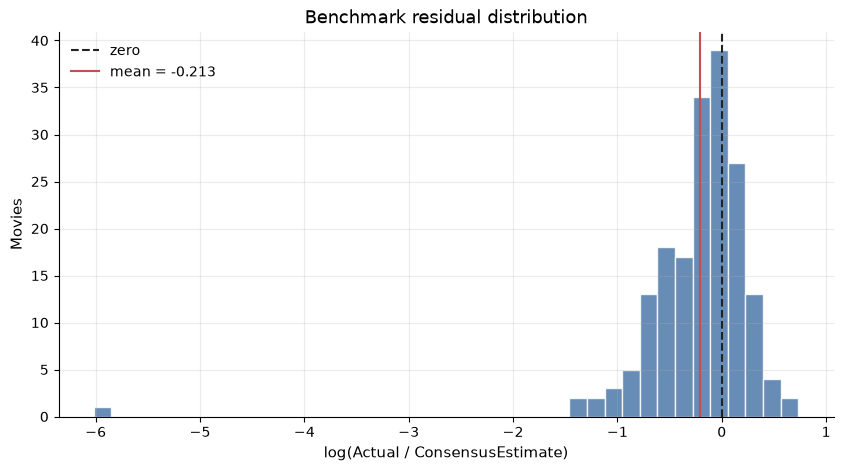

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
e = consensus["benchmark_residual_log"].dropna()
ax.hist(e, bins=40, color="#4c78a8", edgecolor="white", alpha=0.85)
ax.axvline(0, color="#222222", linewidth=1.5, linestyle="--", label="zero")
ax.axvline(e.mean(), color="#c44e52", linewidth=1.5, label=f"mean = {e.mean():.3f}")
ax.set_title("Benchmark residual distribution")
ax.set_xlabel("log(Actual / ConsensusEstimate)")
ax.set_ylabel("Movies")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

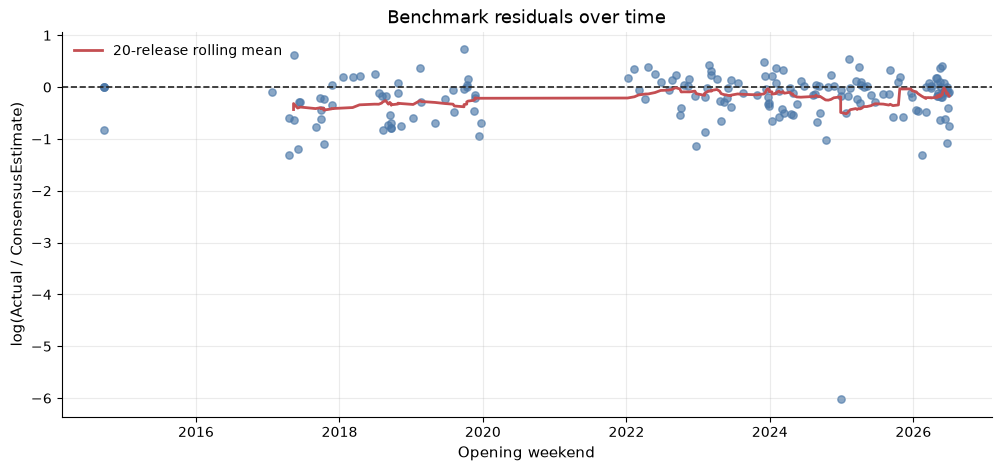

In [15]:
plot_df = consensus.sort_values("opening_weekend_start")
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(plot_df["opening_weekend_start"], plot_df["benchmark_residual_log"], s=28, alpha=0.65, color="#4c78a8")
ax.axhline(0, color="#222222", linewidth=1.2, linestyle="--")
rolling = plot_df.set_index("opening_weekend_start")["benchmark_residual_log"].rolling(20, min_periods=8).mean()
ax.plot(rolling.index, rolling.values, color="#c44e52", linewidth=2, label="20-release rolling mean")
ax.set_title("Benchmark residuals over time")
ax.set_xlabel("Opening weekend")
ax.set_ylabel("log(Actual / ConsensusEstimate)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

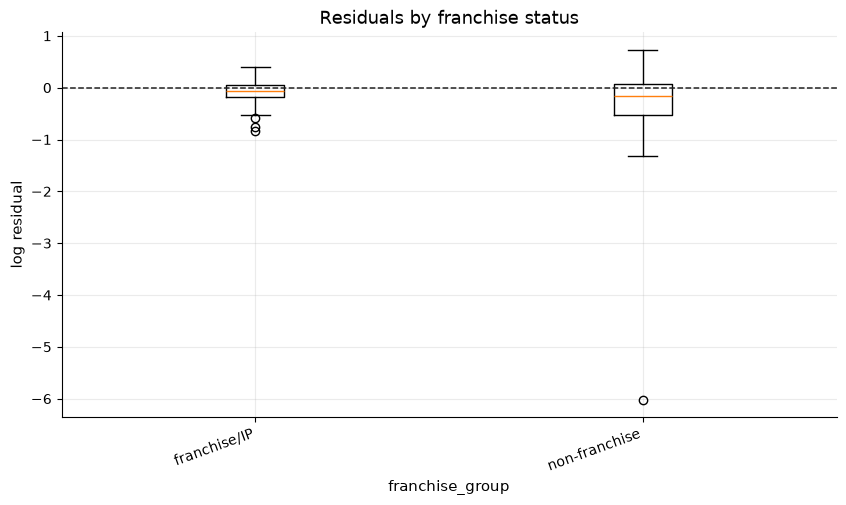

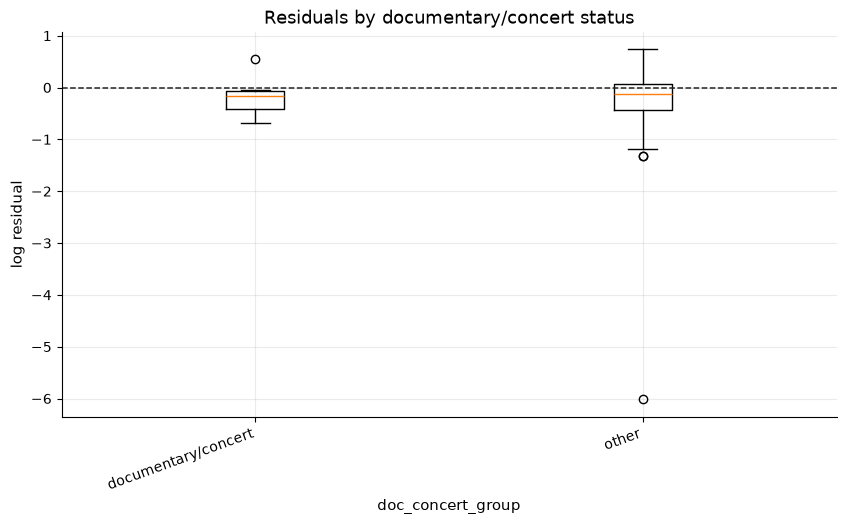

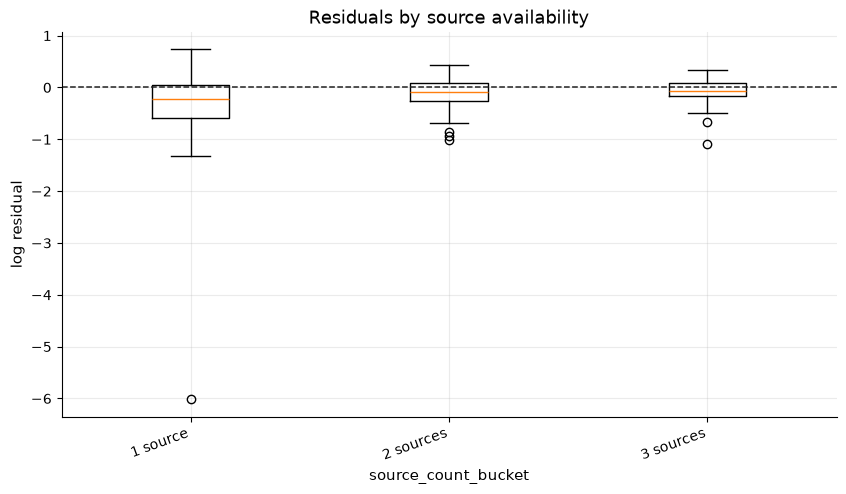

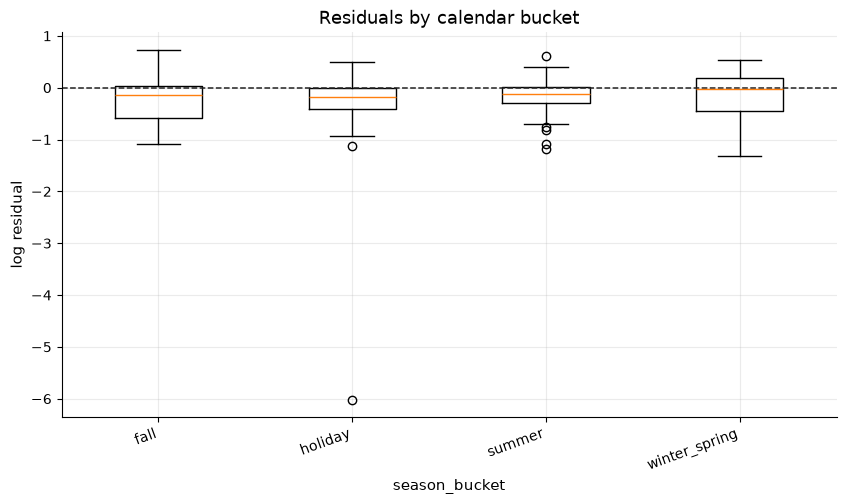

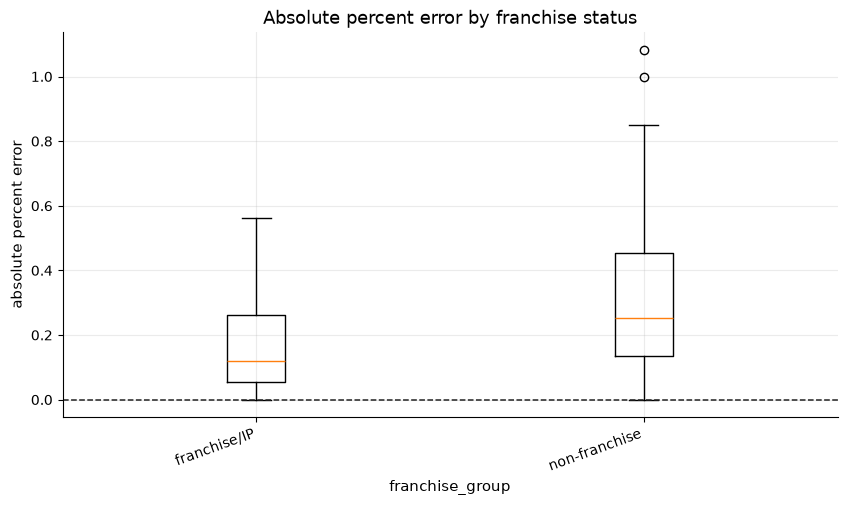

In [16]:
def boxplot_by_group(df, group_col, value_col, title, ylabel):
    plot_df = df[[group_col, value_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if plot_df.empty or plot_df[group_col].nunique() < 1:
        print(f"No data for {title}")
        return
    groups = [g for g in plot_df[group_col].dropna().unique()]
    groups = sorted(groups, key=lambda x: str(x))
    data = [plot_df.loc[plot_df[group_col] == g, value_col] for g in groups]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(data, tick_labels=[str(g) for g in groups], showfliers=True)
    ax.axhline(0, color="#222222", linewidth=1.1, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right")
    plt.show()

plot_groups = consensus.assign(
    franchise_group=np.where(consensus["is_franchise"].fillna(False), "franchise/IP", "non-franchise"),
    doc_concert_group=np.where(consensus["is_doc_concert"].fillna(False), "documentary/concert", "other"),
)

boxplot_by_group(plot_groups, "franchise_group", "benchmark_residual_log", "Residuals by franchise status", "log residual")
boxplot_by_group(plot_groups, "doc_concert_group", "benchmark_residual_log", "Residuals by documentary/concert status", "log residual")
boxplot_by_group(plot_groups, "source_count_bucket", "benchmark_residual_log", "Residuals by source availability", "log residual")
boxplot_by_group(plot_groups, "season_bucket", "benchmark_residual_log", "Residuals by calendar bucket", "log residual")
boxplot_by_group(plot_groups, "franchise_group", "absolute_percent_error", "Absolute percent error by franchise status", "absolute percent error")

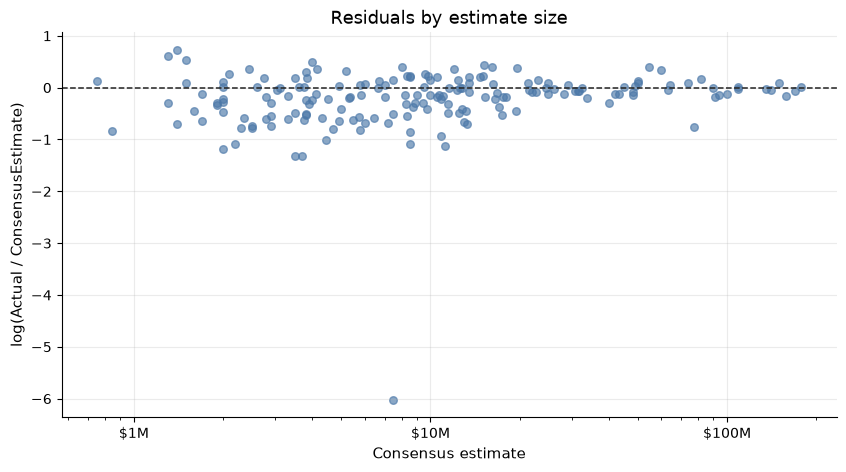

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(consensus["consensus_estimate_usd"], consensus["benchmark_residual_log"], alpha=0.65, s=30, color="#4c78a8")
ax.axhline(0, color="#222222", linewidth=1.1, linestyle="--")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M" if x >= 1_000_000 else f"${x:,.0f}"))
ax.set_title("Residuals by estimate size")
ax.set_xlabel("Consensus estimate")
ax.set_ylabel("log(Actual / ConsensusEstimate)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [18]:
diagnostic_groups = []
for label, group_col in [
    ("franchise", "is_franchise"),
    ("doc_concert", "is_doc_concert"),
    ("source_count", "source_count_bucket"),
    ("season", "season_bucket"),
    ("estimate_size", "estimate_size_bucket"),
]:
    tmp = (
        consensus.groupby(group_col, dropna=False)
        .apply(lambda g: pd.Series(metric_summary(g, str(g.name))).drop(labels=["segment"]))
        .reset_index()
    )
    tmp.insert(0, "diagnostic", label)
    tmp = tmp.rename(columns={group_col: "group"})
    diagnostic_groups.append(tmp)

pd.concat(diagnostic_groups, ignore_index=True)

,diagnostic,group,n,ME_log,MAE_log,RMSE_log,median_actual_to_consensus,median_absolute_percent_error,underprediction_rate,overprediction_rate,source_range_inside_rate
0,franchise,False,127,-0.2628,0.4019,0.7106,0.8455,0.2516,0.3307,0.6535,0.1483
1,franchise,True,53,-0.0940,0.1985,0.2744,0.9448,0.1202,0.3774,0.6038,0.1352
2,doc_concert,False,174,-0.2146,0.3418,0.6207,0.8873,0.2046,0.3506,0.6322,0.1494
3,doc_concert,True,6,-0.1684,0.3490,0.4231,0.8526,0.2763,0.1667,0.8333,0.0000
4,source_count,1 source,81,-0.3258,0.4645,0.8390,0.8001,0.2857,0.3210,0.6420,0.1235
5,source_count,2 sources,71,-0.1241,0.2602,0.3470,0.9164,0.1797,0.3521,0.6479,0.1127
6,source_count,3 sources,28,-0.1128,0.1951,0.3020,0.9397,0.1226,0.3929,0.6071,0.2857
7,season,fall,35,-0.2612,0.3723,0.4953,0.8636,0.2627,0.3143,0.6000,0.1333
8,season,holiday,27,-0.4458,0.5333,1.2325,0.8287,0.2392,0.2593,0.7407,0.0679
9,season,summer,62,-0.1634,0.2601,0.3670,0.8829,0.1548,0.3065,0.6935,0.2204


## Tiny Calibration Model

Only after evaluating the raw benchmark, fit the first residual calibration model:

`e = beta0 + beta1 * Franchise + beta2 * DocConcert + error`

This is fit on train and evaluated on the same chronological test sets as the benchmark.

In [19]:
def design_matrix(df):
    return np.column_stack(
        [
            np.ones(len(df)),
            df["is_franchise"].fillna(False).astype(float).to_numpy(),
            df["is_doc_concert"].fillna(False).astype(float).to_numpy(),
        ]
    )


def fit_tiny_calibration(train):
    model_df = train.dropna(subset=["benchmark_residual_log"]).copy()
    if len(model_df) < 4:
        return None
    x = design_matrix(model_df)
    y = model_df["benchmark_residual_log"].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    residuals = y - x @ beta
    sigma = residuals.std(ddof=x.shape[1]) if len(y) > x.shape[1] else np.nan
    return beta, sigma, len(model_df)

calibration_rows = []
calibrated_test_rows = []
calibrated_coverage_rows = []
for split_name, split_df in split_results.items():
    train = split_df[split_df["split"] == "train"]
    test = split_df[split_df["split"] == "test"].copy()
    fitted = fit_tiny_calibration(train)
    if fitted is None:
        continue
    beta, sigma, n_train = fitted
    calibration_rows.append(
        {
            "split_name": split_name,
            "n_train": n_train,
            "intercept": beta[0],
            "franchise_beta": beta[1],
            "doc_concert_beta": beta[2],
            "calibration_residual_sigma": sigma,
        }
    )
    test["tiny_calibration_predicted_residual"] = design_matrix(test) @ beta
    test["calibrated_forecast_usd"] = np.exp(
        test["log_consensus_estimate"] + test["tiny_calibration_predicted_residual"]
    )
    test["calibrated_80_lower"] = np.exp(
        test["log_consensus_estimate"] + test["tiny_calibration_predicted_residual"] - 1.28 * sigma
    )
    test["calibrated_80_upper"] = np.exp(
        test["log_consensus_estimate"] + test["tiny_calibration_predicted_residual"] + 1.28 * sigma
    )
    test["calibrated_95_lower"] = np.exp(
        test["log_consensus_estimate"] + test["tiny_calibration_predicted_residual"] - 1.96 * sigma
    )
    test["calibrated_95_upper"] = np.exp(
        test["log_consensus_estimate"] + test["tiny_calibration_predicted_residual"] + 1.96 * sigma
    )

    raw = evaluate_forecasts(test, "consensus_estimate_usd", "raw consensus benchmark")
    calibrated = evaluate_forecasts(test, "calibrated_forecast_usd", "tiny residual calibration")
    for row in (raw, calibrated):
        row["split_name"] = split_name
        calibrated_test_rows.append(row)
    calibrated_coverage_rows.append(
        {
            "split_name": split_name,
            "calibrated_80_coverage": interval_coverage(test, "calibrated_80_lower", "calibrated_80_upper"),
            "calibrated_95_coverage": interval_coverage(test, "calibrated_95_lower", "calibrated_95_upper"),
        }
    )

calibration_coefficients = pd.DataFrame(calibration_rows).set_index("split_name")
calibration_test_comparison = pd.DataFrame(calibrated_test_rows).set_index(["split_name", "model"])
calibration_interval_coverage = pd.DataFrame(calibrated_coverage_rows).set_index("split_name")
calibration_coefficients

,n_train,intercept,franchise_beta,doc_concert_beta,calibration_residual_sigma
split_name,,,,,
2010-2019_and_2022-2023_train__2024plus_test,94,-0.2549,0.1763,-0.0079,0.4144
2022-2023_train__2024plus_test,41,-0.0941,0.0613,-0.0001,0.3512


In [20]:
calibration_test_comparison

n  \
split_name                                   model                           
2010-2019_and_2022-2023_train__2024plus_test raw consensus benchmark    86   
                                             tiny residual calibration  86   
2022-2023_train__2024plus_test               raw consensus benchmark    86   
                                             tiny residual calibration  86   

                                                                        ME_log  \
split_name                                   model                               
2010-2019_and_2022-2023_train__2024plus_test raw consensus benchmark   -0.2183   
                                             tiny residual calibration -0.0206   
2022-2023_train__2024plus_test               raw consensus benchmark   -0.2183   
                                             tiny residual calibration -0.1441   

                                                                        MAE_log  \
split_name                                   model                                
2010-2019_and_2022-2023_train__2024plus_test raw consensus benchmark     0.3290   
                                             tiny residual calibration   0.3406   
2022-2023_train__2024plus_test               raw consensus benchmark     0.3290   
                                             tiny residual calibration   0.3188   

                                                                        RMSE_log  \
split_name                                   model                                 
2010-2019_and_2022-2023_train__2024plus_test raw consensus benchmark      0.7458   
                                             tiny residual calibration    0.7094   
2022-2023_train__2024plus_test               raw consensus benchmark      0.7458   
                                             tiny residual calibration    0.7251   

                                                                        MdAPE  
split_name                                   model                             
2010-2019_and_2022-2023_train__2024plus_test raw consensus benchmark   0.1598  
                                             tiny residual calibration 0.2594  
2022-2023_train__2024plus_test               raw consensus benchmark   0.1598  
                                             tiny residual calibration 0.1727

In [21]:
calibration_interval_coverage

,calibrated_80_coverage,calibrated_95_coverage
split_name,,
2010-2019_and_2022-2023_train__2024plus_test,0.8953,0.9651
2022-2023_train__2024plus_test,0.8140,0.9419


## Benchmark Refinement: Bias Correction and Interval Stratification

The consensus estimate is the benchmark to beat. This section audits the largest 2024+ misses, isolates a bias-only correction, compares point forecasts on genuine test data, and tests whether interval groups improve uncertainty calibration.

### Largest 2024+ Misses

These are the biggest absolute benchmark residuals in the 2024+ test period. Use the `notes` column to mark data errors, parsing problems, unusual release types, event films, or genuine misses after inspection.

In [22]:
test_2024_plus = consensus.loc[consensus["release_year"] >= 2024].copy()
test_2024_plus["abs_benchmark_residual_log"] = test_2024_plus["benchmark_residual_log"].abs()

largest_2024_misses = (
    test_2024_plus.sort_values("abs_benchmark_residual_log", ascending=False)
    .head(10)
    .assign(notes="")
    [
        [
            "title",
            "opening_weekend_start",
            "actual_opening_weekend_gross_usd",
            "consensus_estimate_usd",
            "actual_to_consensus",
            "benchmark_residual_log",
            "abs_benchmark_residual_log",
            "is_franchise",
            "genre",
            "is_doc_concert",
            "estimate_source_count",
            "estimate_sources",
            "latest_estimate_date",
            "season_bucket",
            "notes",
        ]
    ]
)
largest_2024_misses

,title,opening_weekend_start,actual_opening_weekend_gross_usd,consensus_estimate_usd,actual_to_consensus,benchmark_residual_log,abs_benchmark_residual_log,is_franchise,genre,is_doc_concert,estimate_source_count,estimate_sources,latest_estimate_date,season_bucket,notes
50,Better Man (2024),2024-12-27,"18,259.0000","7,500,000.0000",0.0024,-6.0180,6.0180,False,Musical,False,1,boxofficetheory,2024-12-20,holiday,
102,Cold Storage (2026),2026-02-13,"936,170.0000","3,500,000.0000",0.2675,-1.3187,1.3187,False,Action,False,1,boxofficetheory,2026-02-06,winter_spring,
109,The Death of Robin Hood,2026-06-19,"2,867,662.0000","8,500,000.0000",0.3374,-1.0866,1.0866,False,Action,False,3,"boxofficepro, boxofficereport, boxofficetheory",2026-06-18,summer,
26,The Apprentice (2024),2024-10-11,"1,613,233.0000","4,450,000.0000",0.3625,-1.0147,1.0147,False,Drama,False,2,"boxofficereport, boxofficetheory",2024-10-10,fall,
134,Minions & Monsters,2026-07-03,"36,400,000.0000","77,500,000.0000",0.4697,-0.7557,0.7557,True,Adventure,False,1,boxofficetheory,2026-07-01,summer,
11,Afraid (2024),2024-08-30,"3,665,664.0000","7,200,000.0000",0.5091,-0.6751,0.6751,False,Horror,False,3,"boxofficepro, boxofficereport, boxofficetheory",2024-08-29,summer,
68,The Book of Clarence (2024),2024-01-12,"2,557,027.0000","4,900,000.0000",0.5218,-0.6504,0.6504,False,Comedy,False,2,"boxofficepro, boxofficereport",2024-01-11,winter_spring,
116,In the Grey (2026),2026-05-15,"2,926,879.0000","5,500,000.0000",0.5322,-0.6308,0.6308,False,Action,False,1,boxofficetheory,2026-05-13,summer,
130,Stop! That! Train!,2026-06-12,"2,024,687.0000","3,750,000.0000",0.5399,-0.6163,0.6163,False,Comedy,False,2,"boxofficereport, boxofficetheory",2026-06-11,summer,
96,Christy (2025),2025-11-07,"1,310,888.0000","2,350,000.0000",0.5578,-0.5837,0.5837,False,Drama,False,2,"boxofficereport, boxofficetheory",2025-11-06,holiday,


### Bias-Only Calibration

The bias-only benchmark estimates one training-set residual mean, `alpha`, then forecasts `ConsensusEstimate * exp(alpha)`. This isolates global optimism correction from segment effects.

In [23]:
def fit_bias_only(train):
    alpha = train["benchmark_residual_log"].dropna().mean()
    return alpha, float(np.exp(alpha))


def add_tiny_calibrated_forecast(train, test):
    fitted = fit_tiny_calibration(train)
    out = test.copy()
    if fitted is None:
        out["tiny_calibrated_forecast_usd"] = np.nan
        return out, np.nan
    beta, sigma, _n_train = fitted
    out["tiny_calibrated_forecast_usd"] = np.exp(out["log_consensus_estimate"] + design_matrix(out) @ beta)
    return out, sigma

point_forecast_rows = []
bias_params_rows = []
for split_name, split_df in split_results.items():
    train = split_df[split_df["split"] == "train"].copy()
    test = split_df[split_df["split"] == "test"].copy()
    alpha, multiplier = fit_bias_only(train)
    bias_params_rows.append(
        {
            "split_name": split_name,
            "n_train": len(train),
            "alpha_log_bias": alpha,
            "bias_multiplier": multiplier,
        }
    )

    test["bias_only_forecast_usd"] = np.exp(test["log_consensus_estimate"] + alpha)
    tiny_test, _tiny_sigma = add_tiny_calibrated_forecast(train, test)

    for forecast_col, label in [
        ("consensus_estimate_usd", "raw consensus"),
        ("bias_only_forecast_usd", "bias-only consensus"),
        ("tiny_calibrated_forecast_usd", "tiny calibration"),
    ]:
        row = evaluate_forecasts(tiny_test, forecast_col, label)
        row["split_name"] = split_name
        point_forecast_rows.append(row)

bias_only_parameters = pd.DataFrame(bias_params_rows).set_index("split_name")
point_forecast_comparison = (
    pd.DataFrame(point_forecast_rows)
    .set_index(["split_name", "model"])
    .sort_index()
)

display(bias_only_parameters)
point_forecast_comparison

,n_train,alpha_log_bias,bias_multiplier
split_name,,,
2010-2019_and_2022-2023_train__2024plus_test,94,-0.2084,0.8119
2022-2023_train__2024plus_test,41,-0.0747,0.9280


n  ME_log  \
split_name                                   model                             
2010-2019_and_2022-2023_train__2024plus_test bias-only consensus  86 -0.0100   
                                             raw consensus        86 -0.2183   
                                             tiny calibration     86 -0.0206   
2022-2023_train__2024plus_test               bias-only consensus  86 -0.1436   
                                             raw consensus        86 -0.2183   
                                             tiny calibration     86 -0.1441   

                                                                  MAE_log  \
split_name                                   model                          
2010-2019_and_2022-2023_train__2024plus_test bias-only consensus   0.3392   
                                             raw consensus         0.3290   
                                             tiny calibration      0.3406   
2022-2023_train__2024plus_test               bias-only consensus   0.3166   
                                             raw consensus         0.3290   
                                             tiny calibration      0.3188   

                                                                  RMSE_log  \
split_name                                   model                           
2010-2019_and_2022-2023_train__2024plus_test bias-only consensus    0.7132   
                                             raw consensus          0.7458   
                                             tiny calibration       0.7094   
2022-2023_train__2024plus_test               bias-only consensus    0.7275   
                                             raw consensus          0.7458   
                                             tiny calibration       0.7251   

                                                                  MdAPE  
split_name                                   model                       
2010-2019_and_2022-2023_train__2024plus_test bias-only consensus 0.2511  
                                             raw consensus       0.1598  
                                             tiny calibration    0.2594  
2022-2023_train__2024plus_test               bias-only consensus 0.1716  
                                             raw consensus       0.1598  
                                             tiny calibration    0.1727

### Interval Stratification

Use the larger training split for interval estimation. Intervals stay on the log scale, estimate training residual SD by group, and then back-transform to dollars. Small training cells fall back to the global residual SD.

In [24]:
INTERVAL_SPLIT_NAME = "2010-2019_and_2022-2023_train__2024plus_test"
interval_df = split_results[INTERVAL_SPLIT_NAME].copy()
interval_train = interval_df[interval_df["split"] == "train"].copy()
interval_test = interval_df[interval_df["split"] == "test"].copy()

large_estimate_cutoff_usd = interval_train["consensus_estimate_usd"].quantile(0.75)

def add_interval_group_columns(df):
    out = df.copy()
    out["franchise_group"] = np.where(out["is_franchise"].fillna(False), "franchise", "non_franchise")
    out["source_count_group"] = np.where(out["estimate_source_count"] == 1, "one_source", "two_plus_sources")
    out["estimate_size_group"] = np.where(
        out["consensus_estimate_usd"] >= large_estimate_cutoff_usd,
        "large_estimate",
        "non_large_estimate",
    )
    return out

interval_train = add_interval_group_columns(interval_train)
interval_test = add_interval_group_columns(interval_test)

def interval_coverage_for_groups(train, test, group_cols, label, *, min_group_n=MIN_GROUP_N_FOR_GROUP_SIGMA):
    train = train.copy()
    test = test.copy()
    global_sigma = train["benchmark_residual_log"].std(ddof=1)
    if group_cols:
        sigma_by_group = (
            train.groupby(group_cols)["benchmark_residual_log"]
            .agg(["count", "std"])
            .reset_index()
        )
        sigma_by_group = sigma_by_group[sigma_by_group["count"] >= min_group_n]
        test = test.merge(
            sigma_by_group[group_cols + ["std"]].rename(columns={"std": "interval_sigma"}),
            on=group_cols,
            how="left",
        )
        used_group_count = len(sigma_by_group)
    else:
        test["interval_sigma"] = global_sigma
        used_group_count = 1
    test["interval_sigma"] = test["interval_sigma"].fillna(global_sigma)
    for interval_name, c in [("80", 1.28), ("95", 1.96)]:
        test[f"{label}_{interval_name}_lower"] = np.exp(test["log_consensus_estimate"] - c * test["interval_sigma"])
        test[f"{label}_{interval_name}_upper"] = np.exp(test["log_consensus_estimate"] + c * test["interval_sigma"])
    return {
        "interval_method": label,
        "group_columns": ", ".join(group_cols) if group_cols else "global",
        "large_estimate_cutoff_usd": large_estimate_cutoff_usd if "estimate_size_group" in group_cols else np.nan,
        "used_group_count": used_group_count,
        "fallback_sigma_log": global_sigma,
        "coverage_80": interval_coverage(test, f"{label}_80_lower", f"{label}_80_upper"),
        "coverage_95": interval_coverage(test, f"{label}_95_lower", f"{label}_95_upper"),
        "mean_80_width_to_consensus": ((test[f"{label}_80_upper"] - test[f"{label}_80_lower"]) / test["consensus_estimate_usd"]).mean(),
        "mean_95_width_to_consensus": ((test[f"{label}_95_upper"] - test[f"{label}_95_lower"]) / test["consensus_estimate_usd"]).mean(),
    }

interval_group_specs = [
    ([], "global_sd"),
    (["franchise_group"], "franchise_sd"),
    (["franchise_group", "source_count_group"], "franchise_source_count_sd"),
    (["franchise_group", "estimate_size_group"], "franchise_estimate_size_sd"),
]
interval_stratification_coverage = pd.DataFrame(
    interval_coverage_for_groups(interval_train, interval_test, cols, label)
    for cols, label in interval_group_specs
)
interval_stratification_coverage

,interval_method,group_columns,large_estimate_cutoff_usd,used_group_count,fallback_sigma_log,coverage_80,coverage_95,mean_80_width_to_consensus,mean_95_width_to_consensus
0,global_sd,global,NaN,1,0.4174,0.8372,0.9535,1.1200,1.8248
1,franchise_sd,franchise_group,NaN,2,0.4174,0.8023,0.9302,1.0491,1.7108
2,franchise_source_count_sd,"franchise_group, source_count_group",NaN,4,0.4174,0.7326,0.8837,0.9113,1.4752
3,franchise_estimate_size_sd,"franchise_group, estimate_size_group","14,562,500.0000",2,0.4174,0.8488,0.9186,1.0113,1.6517


### Current Benchmark Choice

This table applies a conservative rule: keep the simplest point forecast unless calibration clearly improves test errors, and choose the interval grouping with coverage closest to 80%/95% without creating tiny cells.

In [25]:
def choose_point_forecast(comparison, split_name=INTERVAL_SPLIT_NAME):
    rows = comparison.loc[split_name].copy()
    raw = rows.loc["raw consensus"]
    bias = rows.loc["bias-only consensus"]
    tiny = rows.loc["tiny calibration"]

    bias_improves_bias = abs(bias["ME_log"]) < abs(raw["ME_log"])
    bias_does_not_hurt = (bias["MAE_log"] <= raw["MAE_log"] * 1.03) and (bias["MdAPE"] <= raw["MdAPE"] * 1.05)
    tiny_clearly_beats_bias = (
        (tiny["MAE_log"] < bias["MAE_log"])
        and (tiny["RMSE_log"] < bias["RMSE_log"])
        and (tiny["MdAPE"] <= bias["MdAPE"])
    )
    if tiny_clearly_beats_bias:
        return "tiny calibration", "beats bias-only on MAE, RMSE, and MdAPE in the larger chronological split"
    if bias_improves_bias and bias_does_not_hurt:
        return "bias-only consensus", "reduces log bias without materially hurting MAE or MdAPE"
    return "raw consensus", "calibration does not clearly improve test MAE/MdAPE enough to justify changing the point forecast"


def choose_interval_method(coverage):
    scored = coverage.copy()
    scored["coverage_score"] = (scored["coverage_80"] - 0.80).abs() + (scored["coverage_95"] - 0.95).abs()
    scored["small_cell_penalty"] = np.where(scored["used_group_count"] > 4, 0.02, 0.0)
    scored["selection_score"] = scored["coverage_score"] + scored["small_cell_penalty"]
    winner = scored.sort_values("selection_score").iloc[0]
    return winner["interval_method"], f"80% coverage={winner['coverage_80']:.3f}, 95% coverage={winner['coverage_95']:.3f} on 2024+ test"

point_choice, point_reason = choose_point_forecast(point_forecast_comparison)
interval_choice, interval_reason = choose_interval_method(interval_stratification_coverage)

current_benchmark_choice = pd.DataFrame(
    [
        {
            "component": "point forecast",
            "choice": point_choice,
            "reason": point_reason,
        },
        {
            "component": "prediction interval",
            "choice": interval_choice,
            "reason": interval_reason,
        },
    ]
)
current_benchmark_choice

,component,choice,reason
0,point forecast,raw consensus,calibration does not clearly improve test MAE/...
1,prediction interval,franchise_sd,"80% coverage=0.802, 95% coverage=0.930 on 2024..."


## Export Analysis Table

This writes a compact CSV with one row per eligible release and the benchmark residual fields. It is useful for model notebooks that should begin from the benchmark error rather than rebuilding this join.

In [26]:
export_path = repo_root / "data" / "diagnostics" / "late_forecast_consensus_benchmark.csv"
export_path.parent.mkdir(parents=True, exist_ok=True)
consensus.sort_values("opening_weekend_start").to_csv(export_path, index=False)
export_path

PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_consensus_benchmark.csv')